# Chemical space (ECFP4 → UMAP)

Set the runs root, choose which runs to include (or leave as None for all), and pick the per-run sample size. The code below will load records, compute ECFP4 fingerprints, and plot a simple UMAP.

In [1]:
import os

os.chdir("/mnt/delta/code/collab/bench")

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt
from rdkit import DataStructs
import umap

from experiments.common import find_runs, load_records, init_plots, FIG_WIDTH_IN, FIG_HEIGHT_IN
from utils.analysis import morgan_fps


2025-12-03 09:39:32.811517: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-03 09:39:32.823053: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-03 09:39:32.826657: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-03 09:39:32.836013: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 09:39:33.563834: W tensorflow/compiler/tf2

Skipped polaris_novartis-adme-novartis-cyp3a4-reg_split: No records.csv found in /mnt/delta/code/collab/bench/runs/polaris/polaris_novartis-adme-novartis-cyp3a4-reg_split
Skipped polaris_polaris-adme-fang-solu-1_split: No records.csv found in /mnt/delta/code/collab/bench/runs/polaris/polaris_polaris-adme-fang-solu-1_split
Skipped tdc_bbb_martins_random: No records.csv found in /mnt/delta/code/collab/bench/runs/tdc/tdc_bbb_martins_random
Skipped tdc_bbb_martins_scaffold: No records.csv found in /mnt/delta/code/collab/bench/runs/tdc/tdc_bbb_martins_scaffold
Skipped tdc_bioavailability_ma_random: No records.csv found in /mnt/delta/code/collab/bench/runs/tdc/tdc_bioavailability_ma_random
Skipped tdc_bioavailability_ma_scaffold: No records.csv found in /mnt/delta/code/collab/bench/runs/tdc/tdc_bioavailability_ma_scaffold
Skipped tdc_caco2_wang_random: No records.csv found in /mnt/delta/code/collab/bench/runs/tdc/tdc_caco2_wang_random
Skipped tdc_caco2_wang_scaffold: No records.csv found in 

/tmp/ipykernel_476/35336157.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), sample_per_run), random_state=42))
/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


<Figure size 800x400 with 0 Axes>

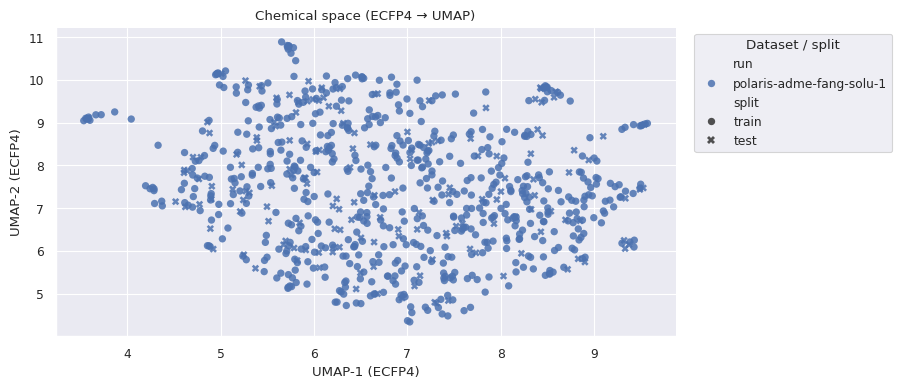

In [5]:
# Configure here
run_root = Path("runs")          # change to your runs directory
selected_runs = None              # e.g., ["tdc_caco2_wang_scaffold"]; None = all
sample_per_run = 800              # max molecules per run

init_plots()

runs = find_runs(run_root, include_dti=False)
if selected_runs:
    runs = [r for r in runs if r.name in set(selected_runs)]

frames = []
for run in runs:
    try:
        df = load_records(run)
    except Exception as exc:
        print(f"Skipped {run.name}: {exc}")
        continue
    if "smiles_clean" not in df.columns:
        continue
    if "valid" in df.columns:
        df = df[df["valid"]]
    df = df[df["smiles_clean"].notna() & (df["smiles_clean"] != "")]
    df["run"] = run.name
    frames.append(df)

if not frames:
    print("No valid SMILES to plot.")
else:
    combined = pd.concat(frames, ignore_index=True)
    combined = (
        combined.groupby("run", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), sample_per_run), random_state=42))
        .reset_index(drop=True)
    )

    fps = morgan_fps(combined["smiles_clean"].tolist(), radius=2, n_bits=2048)
    keep = [(idx, fp) for idx, fp in enumerate(fps) if fp is not None]
    if not keep:
        print("No valid fingerprints.")
    else:
        def _fp_to_array(fp, n_bits=2048):
            arr = np.zeros((n_bits,), dtype=np.float32)
            DataStructs.ConvertToNumpyArray(fp, arr)
            return arr

        arr = np.stack([_fp_to_array(fp) for _, fp in keep])
        reducer = umap.UMAP(random_state=42)
        emb = reducer.fit_transform(arr)
        meta = combined.iloc[[idx for idx, _ in keep]][["run", "split"]].reset_index(drop=True)
        embed_df = pd.concat([meta, pd.DataFrame({"UMAP-1": emb[:, 0], "UMAP-2": emb[:, 1]})], axis=1)

        fig, ax = plt.subplots(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))
        sns.scatterplot(
            data=embed_df,
            x="UMAP-1",
            y="UMAP-2",
            hue="run",
            style="split",
            s=28,
            alpha=0.85,
            linewidth=0,
            ax=ax,
        )
        ax.set_title("Chemical space (ECFP4 → UMAP)")
        ax.set_xlabel("UMAP-1 (ECFP4)")
        ax.set_ylabel("UMAP-2 (ECFP4)")
        sns.despine(ax=ax)
        ax.legend(title="Dataset / split", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.show()
        plt.close(fig)
